In [ ]:
"""
Audiogram severity classification using CNN + InceptionResNetV2 (transfer learning)

Folder structure expected:
dataset_split.1/
  train/
    class_a/
    class_b/
    ...
  test/
    class_a/
    class_b/
    ...

This script:
- builds an ImageDataGenerator pipeline
- trains with frozen base
- (optionally) fine-tunes top layers
- saves a .keras model and class_indices.json
- provides a helper predict_severity() for inference
"""

import os
import json
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    Conv2D, BatchNormalization, Activation
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


# ==========================
# 0. CONFIG
# ==========================
BASE_DIR = "dataset_split.1"          # change if different
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (299, 299)                # InceptionResNetV2 default
BATCH_SIZE = 32

EPOCHS_FROZEN = 25
EPOCHS_FINE_TUNE = 15

MODEL_SAVE_PATH = "audiogram_severity_inceptionresnetv2.keras"
CLASS_MAP_PATH  = "class_indices.json"
BEST_CHECKPOINT_PATH = "best_model.keras"


# ==========================
# 1. Data generators (folders)
# ==========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.05,
    horizontal_flip=False,        # audiograms usually shouldn’t flip
    validation_split=0.2          # take 20% of TRAIN as validation
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("\nClasses:", train_generator.class_indices)

# Save mapping for later inference
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(train_generator.class_indices, f, indent=2)
print("Saved class mapping to:", CLASS_MAP_PATH)


# ==========================
# 2. Class weights (optional, helps imbalance)
# ==========================
class_labels = list(train_generator.class_indices.keys())
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_labels),
    y=[class_labels[i] for i in train_generator.classes],
)
class_weight = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)


# ==========================
# 3. Build model (CNN + InceptionResNetV2 transfer learning)
# ==========================
base_model = InceptionResNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)

base_model.trainable = False  # freeze first

# Small CNN head on top of backbone feature map (CNN-InceptionResNetV2)
x = base_model.output
x = Conv2D(256, (3, 3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
preds = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=preds)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==========================
# 4. Callbacks
# ==========================
callbacks = [
    ModelCheckpoint(BEST_CHECKPOINT_PATH, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]


# ==========================
# 5. Train (frozen base)
# ==========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)


# ==========================
# 6. Fine-tune (optional)
# ==========================
# InceptionResNetV2 is deeper than InceptionV3, so use a higher index
fine_tune_at = 600  # adjust if needed

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)


# ==========================
# 7. Evaluate + save
# ==========================
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_true = test_generator.classes
y_prob = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
target_names = [idx_to_class[i] for i in range(num_classes)]

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

model.save(MODEL_SAVE_PATH)
print("\nSaved model to:", MODEL_SAVE_PATH)


# ==========================
# 8. Inference helper
# ==========================
def predict_severity(image_path: str):
    """
    Returns: (pred_label, confidence, probs)
    """
    mdl = load_model(MODEL_SAVE_PATH)

    with open(CLASS_MAP_PATH, "r") as f:
        class_indices = json.load(f)
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    img = load_img(image_path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # IMPORTANT for InceptionResNetV2

    probs = mdl.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class_local[pred_idx]
    confidence = float(probs[pred_idx])
    return pred_label, confidence, probs


if __name__ == "__main__":
    # Example:
    # label, conf, probs = predict_severity("some_audiogram.png")
    # print(label, conf)
    pass


In [1]:
import os
import json
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    Conv2D, BatchNormalization, Activation
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

c:\Users\user\OneDrive\Desktop\speechbanana\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ==========================
# 0. CONFIG
# ==========================
BASE_DIR = "dataset_split.1"          # change if different
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (299, 299)                # InceptionResNetV2 default
BATCH_SIZE = 32

EPOCHS_FROZEN = 25
EPOCHS_FINE_TUNE = 15

MODEL_SAVE_PATH = "audiogram_severity_inceptionresnetv2.keras"
CLASS_MAP_PATH  = "class_indices.json"
BEST_CHECKPOINT_PATH = "best_model.keras"

In [4]:

# 1. Data generators (folders)
# ==========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.05,
    horizontal_flip=False,        # audiograms usually shouldn’t flip
    validation_split=0.2          # take 20% of TRAIN as validation
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("\nClasses:", train_generator.class_indices)

# Save mapping for later inference
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(train_generator.class_indices, f, indent=2)
print("Saved class mapping to:", CLASS_MAP_PATH)


Found 511 images belonging to 6 classes.
Found 123 images belonging to 6 classes.
Found 199 images belonging to 6 classes.

Classes: {'Mild': 0, 'Moderate': 1, 'Moderately severe': 2, 'Normal': 3, 'Profound': 4, 'Severe': 5}
Saved class mapping to: class_indices.json


In [5]:
# ==========================
# 2. Class weights (optional, helps imbalance)
# ==========================
class_labels = list(train_generator.class_indices.keys())
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_labels),
    y=[class_labels[i] for i in train_generator.classes],
)
class_weight = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)

Class weights: {0: 0.8268608414239482, 1: 0.8602693602693603, 2: 0.9789272030651341, 3: 0.8268608414239482, 4: 1.9356060606060606, 5: 1.1355555555555557}


In [6]:
# ==========================
# 3. Build model (CNN + InceptionResNetV2 transfer learning)
# ==========================
base_model = InceptionResNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)

base_model.trainable = False  # freeze first

# Small CNN head on top of backbone feature map (CNN-InceptionResNetV2)
x = base_model.output
x = Conv2D(256, (3, 3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
preds = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=preds)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 912s 4us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 58,011,622 (221.30 MB)

 Trainable params: 3,674,374 (14.02 MB)

 Non-trainable params: 54,337,248 (207.28 MB)

In [7]:
# ==========================
# 4. Callbacks
# ==========================
callbacks = [
    ModelCheckpoint(BEST_CHECKPOINT_PATH, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]


In [8]:
# ==========================
# 5. Train (frozen base)
# ==========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)


Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3508 - loss: 1.5489 
Epoch 1: val_accuracy improved from None to 0.26016, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 318s 18s/step - accuracy: 0.4247 - loss: 1.4396 - val_accuracy: 0.2602 - val_loss: 1.6822 - learning_rate: 1.0000e-04
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5451 - loss: 1.1551 
Epoch 2: val_accuracy improved from 0.26016 to 0.48780, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 196s 12s/step - accuracy: 0.5753 - loss: 1.1000 - val_accuracy: 0.4878 - val_loss: 1.3388 - learning_rate: 1.0000e-04
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6761 - loss: 0.9366
Epoch 3: val_accuracy improved from 0.48780 to 0.67480, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 160s 10s/s

In [11]:
# ==========================
# 7. Evaluate + save
# ==========================
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_true = test_generator.classes
y_prob = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
target_names = [idx_to_class[i] for i in range(num_classes)]

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

model.save(MODEL_SAVE_PATH)
print("\nSaved model to:", MODEL_SAVE_PATH)


Evaluating on test set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 8s/step - accuracy: 0.7487 - loss: 0.5945
Test loss: 0.5945 | Test accuracy: 0.7487

Classification report:
                   precision    recall  f1-score   support

             Mild       1.00      0.38      0.55        40
         Moderate       0.64      0.97      0.78        39
Moderately severe       0.73      0.71      0.72        34
           Normal       0.78      1.00      0.88        40
         Profound       0.92      0.71      0.80        17
           Severe       0.71      0.69      0.70        29

         accuracy                           0.75       199
        macro avg       0.80      0.74      0.74       199
     weighted avg       0.79      0.75      0.73       199


Confusion matrix:
[[15 14  0 11  0  0]
 [ 0 38  1  0  0  0]
 [ 0  7 24  0  0  3]
 [ 0  0  0 40  0  0]
 [ 0  0  0  0 12  5]
 [ 0  0  8  0  1 20]]

Saved model to: audiogram_severity_inceptionresnetv2.keras


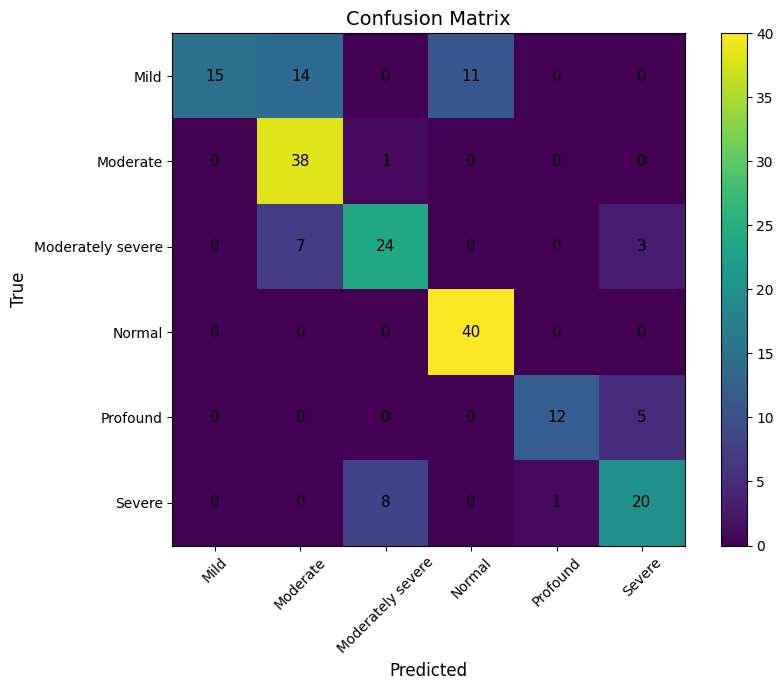

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Define your class names (IMPORTANT)
class_names = [
    "Mild",
    "Moderate",
    "Moderately severe",
    "Normal",
    "Profound",
    "Severe"
]

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

# 4. Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11
        )

# 5. Add colorbar (this gives the exact look you showed)
plt.colorbar()

plt.tight_layout()
plt.show()


In [10]:
# 8. Inference helper
# ==========================
def predict_severity(image_path: str):
    """
    Returns: (pred_label, confidence, probs)
    """
    mdl = load_model(MODEL_SAVE_PATH)

    with open(CLASS_MAP_PATH, "r") as f:
        class_indices = json.load(f)
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    img = load_img(image_path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # IMPORTANT for InceptionResNetV2

    probs = mdl.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class_local[pred_idx]
    confidence = float(probs[pred_idx])
    return pred_label, confidence, probs


if __name__ == "__main__":
    # Example:
    # label, conf, probs = predict_severity("some_audiogram.png")
    # print(label, conf)
    pass

In [13]:
test_image_path = "C://Users//user//OneDrive//Desktop//speechbanana//test4.png"   # <-- change this
label, conf, probs = predict_severity(test_image_path)

print("Predicted label:", label)
print("Confidence:", round(conf * 100, 2), "%")
print("All probs:", probs)


Predicted label: Severe
Confidence: 64.78 %
All probs: [2.1323308e-04 8.0870921e-03 3.3811557e-01 2.4537396e-04 5.5733547e-03
 6.4776534e-01]


In [15]:
test_image_path = "C://Users//user//OneDrive//Desktop//speechbanana//test5.png"   # <-- change this
label, conf, probs = predict_severity(test_image_path)

print("Predicted label:", label)
print("Confidence:", round(conf * 100, 2), "%")
print("All probs:", probs)

Predicted label: Moderate
Confidence: 61.8 %
All probs: [0.27474567 0.617973   0.03178597 0.06488622 0.0041669  0.00644217]


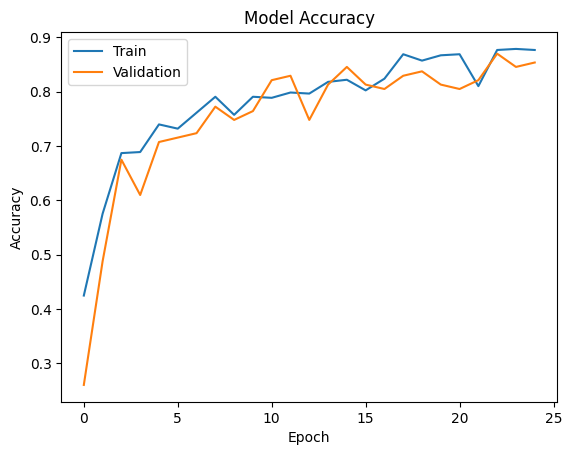

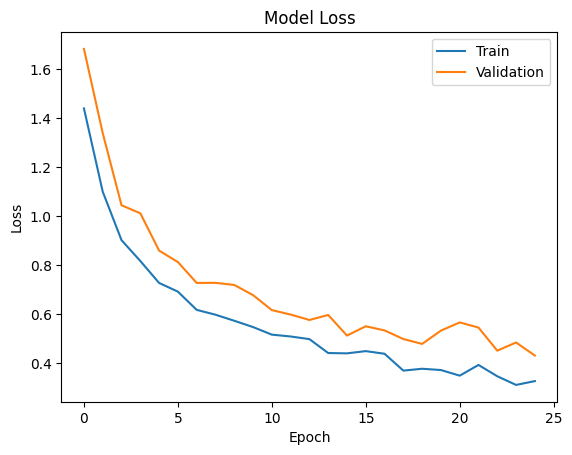

In [16]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()
